<a href="https://colab.research.google.com/github/e-eki/rsna-pneumonia-yolo-pipeline/blob/development/actual_yolo_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# notebooks/colab_train.ipynb

In [ ]:
# ============================================================
# Ячейка 2: Проверка GPU
# ============================================================
# Runtime → Change runtime type → T4 GPU
!nvidia-smi

Fri Oct  2 10:28:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

True Tesla T4


In [2]:
# ============================================================
# Ячейка 3: Клонирование репозитория (ветка development)
# ============================================================
%cd /content

# Если папка уже существует (от прошлого запуска) — удалим, чтобы клон был чистым
!rm -rf rsna-pneumonia-yolo-pipeline

!git clone -b development https://github.com/e-eki/rsna-pneumonia-yolo-pipeline.git


/content
Cloning into 'rsna-pneumonia-yolo-pipeline'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 113 (delta 53), reused 80 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 967.24 KiB | 3.14 MiB/s, done.
Resolving deltas: 100% (53/53), done.


In [9]:
%cd rsna-pneumonia-yolo-pipeline
!git branch --show-current

/content/rsna-pneumonia-yolo-pipeline
development


In [10]:
# ============================================================
# Ячейка 4: Установка зависимостей
# ============================================================
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 10.1 MB/s eta 0:00:00


In [11]:
# ============================================================
# Ячейка 5: Настройка Kaggle API через Colab Secrets
# ============================================================
# Токен хранится в Colab Secrets (🔑 на левой панели), НЕ в коде.
# Name секрета: KAGGLE_API_TOKEN, Value: KGAT_...
import os

try:
    from google.colab import userdata
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    print("✅ KAGGLE_API_TOKEN загружен из Colab Secrets")
except Exception as e:
    raise RuntimeError(
        "Не удалось получить KAGGLE_API_TOKEN. "
        "Добавьте секрет с этим именем в 🔑 на левой панели Colab."
    ) from e

# Проверка, что CLI видит токен
!kaggle datasets metadata poeticmage/rsna-pneumonia-detection-challenge-train-val

✅ KAGGLE_API_TOKEN загружен из Colab Secrets
Downloaded metadata to /content/rsna-pneumonia-yolo-pipeline/dataset-metadata.json


In [12]:
# ============================================================
# Ячейка 6: Скачивание датасета
# ============================================================
!python -m src.download_data --config configs/config.yaml



2026-10-03 11:31:30 | INFO | __main__ | Скачивание датасета: poeticmage/rsna-pneumonia-detection-challenge-train-val
2026-10-03 11:31:30 | INFO | __main__ | Целевая директория: /content/rsna-pneumonia-yolo-pipeline/data/raw
2026-10-03 11:35:21 | INFO | __main__ | Датасет успешно скачан и распакован
2026-10-03 11:35:21 | INFO | __main__ | Готово. Данные в: data/raw


In [13]:
# --- Быстрая проверка структуры датасета ---
!echo "train images: $(ls data/raw/rsna_yolo/images/train | wc -l)"
!echo "train labels: $(ls data/raw/rsna_yolo/labels/train | wc -l)"
!echo "train labels с боксами: $(find data/raw/rsna_yolo/labels/train -name '*.txt' -size +0c | wc -l)"
!echo "val images:   $(ls data/raw/rsna_yolo/images/val | wc -l)"
!echo "val labels с боксами: $(find data/raw/rsna_yolo/labels/val -name '*.txt' -size +0c | wc -l)"

train images: 18678
train labels: 18678
train labels с боксами: 4208
val images:   8006
val labels с боксами: 1804


In [14]:
# ============================================================
# Ячейка 6: Подготовка датасета
# ============================================================

# ============================================================
# : Предобработка + фильтрация «плохой» разметки
# ============================================================
!python src/preprocess.py --config configs/config.yaml
# В логе — сводка: сколько боксов оставлено/отвергнуто,
# сколько изображений перемещено в staged/rejected_images/


!rm -rf data/processed data/staged data/samples
!python -m src.prepare_yolo_dataset --config configs/config.yaml

Traceback (most recent call last):
  File "/content/rsna-pneumonia-yolo-pipeline/src/preprocess.py", line 38, in <module>
    from src.utils import load_config, ensure_dirs, setup_logging, get_logger
ModuleNotFoundError: No module named 'src'
2026-10-03 11:42:16 | INFO | __main__ | Источник:              data/raw/rsna_yolo
2026-10-03 11:42:16 | INFO | __main__ | Назначение processed:  data/processed
2026-10-03 11:42:16 | INFO | __main__ | Назначение rejected:   data/samples/rejected
2026-10-03 11:42:16 | INFO | __main__ | Формат вывода:         jpg (jpeg_quality=92)
2026-10-03 11:42:16 | INFO | __main__ | [train] Изображений: 18678 (output_format=jpg)
2026-10-03 11:45:54 | WARNING | __main__ | [train] 8da6abd4-8940-4696-bc43-6f0891cb7493: all_rejected=False, critical=True → rejected_images/
2026-10-03 11:49:27 | INFO | __main__ | [train] positive=4207, negative=14470, all_rejected=0, critical_rejected=1, dropped_to_rejected=1
2026-10-03 11:49:27 | INFO | __main__ | [train] boxes: total

In [ ]:
!ls data/processed
!ls data/processed/images/train | head -2
!ls data/processed/labels/train | head -2

data.yaml  images  labels
000924cf-0f8d-42bd-9158-1af53881a557.jpg
000fe35a-2649-43d4-b027-e67796d412e0.jpg
000924cf-0f8d-42bd-9158-1af53881a557.txt
000fe35a-2649-43d4-b027-e67796d412e0.txt


In [ ]:
import pandas as pd
df = pd.read_csv("data/samples/rejected/rejected_annotations.csv")
print(df.to_string())

                              patientId  split          x           y       width  height    x_norm    y_norm    w_norm    h_norm          reject_reason  critical
0  8da6abd4-8940-4696-bc43-6f0891cb7493  train  592.00000  560.000512  320.000000   464.0  0.734375  0.773438  0.312500  0.453125  extends_out_of_bounds      True
1  847f25e9-6983-4c5f-a1e6-f3629557f1a3    val   75.00032  816.000512  307.999744   208.0  0.223633  0.898438  0.300781  0.203125  extends_out_of_bounds      True


In [ ]:
# ── ЭТАП 1: статистика по processed (числа, графики) ──
# ============================================================
# ЭТАП 1: RAW — визуальная проверка исходников
# ============================================================

!python -m src.analyze_annotations --stage processed --split train
!python -m src.analyze_annotations --stage processed --split val

2026-10-02 10:49:03 | INFO | __main__ | Изображений: 18677, боксов: 6707
2026-10-02 10:49:03 | INFO | __main__ | Боксов: 6707
2026-10-02 10:49:04 | INFO | __main__ | ✅ Все YOLO-координаты в допустимых диапазонах
2026-10-02 10:49:04 | INFO | __main__ | Отчёт: data/reports/processed_train/report.json
2026-10-02 10:49:04 | INFO | __main__ | Графики: data/reports/processed_train
2026-10-02 10:49:06 | INFO | __main__ | Изображений: 8005, боксов: 2844
2026-10-02 10:49:06 | INFO | __main__ | Боксов: 2844
2026-10-02 10:49:07 | INFO | __main__ | ✅ Все YOLO-координаты в допустимых диапазонах
2026-10-02 10:49:07 | INFO | __main__ | Отчёт: data/reports/processed_val/report.json
2026-10-02 10:49:07 | INFO | __main__ | Графики: data/reports/processed_val


In [ ]:
# ── ЭТАП 2: визуальная проверка processed (контактные листы) ──
!python -m src.sample_and_draw --stage processed --split train --num 50 --grid
!python -m src.sample_and_draw --stage processed --split val   --num 50 --grid

2026-10-02 10:49:30 | INFO | __main__ | Собрано 18677 изображений из data/processed/images/train
2026-10-02 10:49:30 | INFO | __main__ | Сэмплировано 50 из 18677
2026-10-02 10:49:30 | INFO | __main__ | Отрисовано 50 изображений в data/samples/processed/train
2026-10-02 10:49:30 | INFO | __main__ | Метаданные: data/samples/processed/train/metadata.json
2026-10-02 10:49:30 | INFO | __main__ | Контактный лист: data/samples/processed/train/contact_sheet.jpg
2026-10-02 10:49:32 | INFO | __main__ | Собрано 8005 изображений из data/processed/images/val
2026-10-02 10:49:32 | INFO | __main__ | Сэмплировано 50 из 8005
2026-10-02 10:49:33 | INFO | __main__ | Отрисовано 50 изображений в data/samples/processed/val
2026-10-02 10:49:33 | INFO | __main__ | Метаданные: data/samples/processed/val/metadata.json
2026-10-02 10:49:33 | INFO | __main__ | Контактный лист: data/samples/processed/val/contact_sheet.jpg


In [ ]:
# ── ЭТАП 3: визуализация отвергнутых ──
!python -m src.collect_rejected --config configs/config.yaml

2026-10-01 11:28:51 | INFO | __main__ | Отвергнутых аннотаций: 2
2026-10-01 11:28:51 | INFO | __main__ | Сохранено 2 отвергнутых изображений в data/samples/rejected/drawn
2026-10-01 11:28:51 | INFO | __main__ | Смотреть: python -m src.viewer --dir data/samples/rejected/drawn


In [ ]:
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets

FOLDER = Path("data/samples/processed/val")
paths = sorted(FOLDER.glob("*.jpg"))

slider = widgets.IntSlider(min=0, max=len(paths) - 1, step=1,
                           description=f"0/{len(paths)-1}")
out = widgets.Output()

def render(idx):
    with out:
        out.clear_output(wait=True)
        print(paths[idx].name)
        display(Image(str(paths[idx]), width=800))

widgets.interactive_output(render, {"idx": slider})
display(slider, out)

#  Можно подставить любую папку: data/samples/processed/train, data/samples/processed/val, data/samples/rejected/drawn

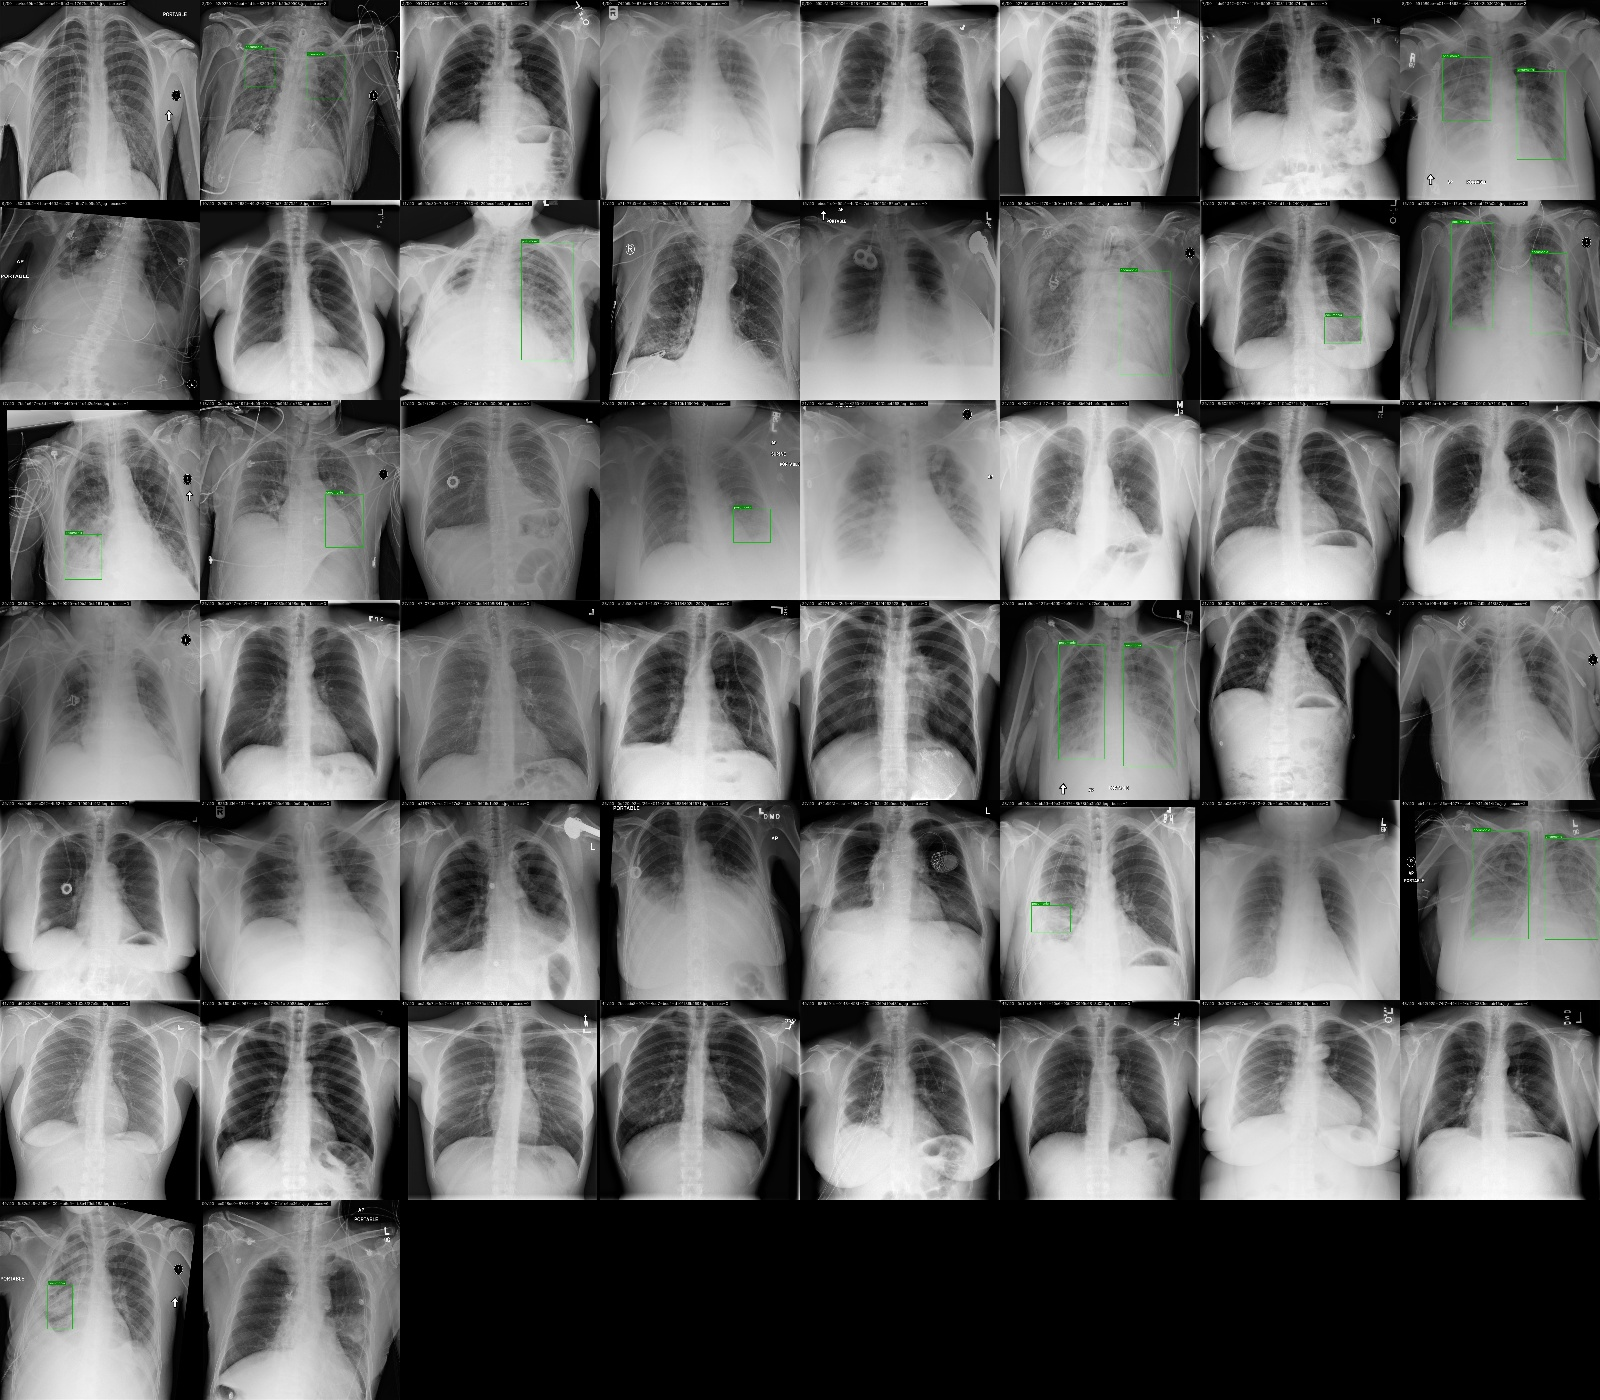

In [ ]:
from IPython.display import Image, display
# display(Image("data/samples/processed/train/contact_sheet.jpg", width=1000))
display(Image("data/samples/processed/val/contact_sheet.jpg", width=1000))

In [ ]:
# ── ЭТАП 4: обучение ──
!rm -rf runs/train
!python -m src.train --config configs/config.yaml

# !python -m src.evaluate --config configs/config.yaml

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
2026-10-03 11:53:57 | INFO | __main__ | Загрузка модели: yolov8s.pt
2026-10-03 11:53:57 | INFO | __main__ | Начало обучения: 30 эпох, batch=16, run_name='run_20261003_1153'
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/processed/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None,

In [ ]:
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets

FOLDER = Path("runs/train")
paths = sorted(FOLDER.glob("*.png"))

slider = widgets.IntSlider(min=0, max=len(paths) - 1, step=1,
                           description=f"0/{len(paths)-1}")
out = widgets.Output()

def render(idx):
    with out:
        out.clear_output(wait=True)
        print(paths[idx].name)
        display(Image(str(paths[idx]), width=800))

widgets.interactive_output(render, {"idx": slider})
display(slider, out)

IntSlider(value=0, description='0/6', max=6)

Output()

In [ ]:
# ============================================================
# Ячейка 11: Сохранение результатов на Google Drive
# ============================================================

# 1. Подключить Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Упаковываем только runs/ и кладём на Drive
!tar -czf /content/drive/MyDrive/rsna-runs_3.10.tar.gz \
     -C /content/rsna-pneumonia-yolo-pipeline runs

# Проверка
!ls -lh /content/drive/MyDrive/rsna-runs_3.10.tar.gz

-rw------- 1 root root 27M Oct  2 13:17 /content/drive/MyDrive/rsna-runs.tar.gz


In [ ]:
# Оценка обученной модели на валидационной выборке

# Возьмёт последнюю best.pt в runs/, а имя выведет сам
# !python -m src.evaluate --config configs/config.yaml

# Явно указали модель
!python -m src.evaluate --config configs/config.yaml --model runs/train/2026-10-02_smoke_yolov8n_3ep/weights/best.pt

2026-10-02 13:05:10 | INFO | __main__ | Имя для результатов выведено из пути модели: 2026-10-02_smoke_yolov8n_3ep
2026-10-02 13:05:10 | INFO | __main__ | Загрузка модели: runs/train/2026-10-02_smoke_yolov8n_3ep/weights/best.pt
2026-10-02 13:05:10 | INFO | __main__ | Запуск валидации: conf=0.001, iou=0.6 (для mAP)
2026-10-02 13:05:10 | INFO | __main__ | Запуск валидации: conf=0.001, iou=0.6 (для mAP)
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1921.3±455.1 MB/s, size: 128.2 KB)
val: Scanning /content/rsna-pneumonia-yolo-pipeline/data/processed/labels/val.cache... 8005 images, 6202 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8005/8005 1.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 501/501 5.0it/s 1:41
                   all       8005       2844    

In [ ]:
# ============================================================
# Ячейка 12 (опционально): Итоговая сводка по пайплайну
# ============================================================
import json
from pathlib import Path
import pandas as pd

print("=" * 60)
print("СВОДКА ПО ПАЙПЛАЙНУ")
print("=" * 60)

# Отчёты по стадиям
for stage_dir in ["data/reports/raw", "data/reports/staged",
                  "data/reports/processed_train", "data/reports/processed_val"]:
    report = Path(stage_dir) / "report.json"
    if report.exists():
        data = json.load(open(report))
        print(f"\n[{stage_dir}]")
        print(f"  боксов:               {data.get('num_boxes')}")
        bpi = data.get("boxes_per_image", {})
        print(f"  изображений с боксами: {bpi.get('with_boxes')}")
        print(f"  изображений без боксов:{bpi.get('without_boxes')}")
        if "yolo_out_of_bounds" in data:
            print(f"  YOLO out-of-bounds:    {data['yolo_out_of_bounds']}")
        if "pixel_out_of_bounds_images" in data:
            print(f"  pixel out-of-bounds:   {data['pixel_out_of_bounds_images']}")

# Отчёт фильтрации
filt = Path("data/staged/filtering_report.json")
if filt.exists():
    data = json.load(open(filt))
    print(f"\n[Фильтрация]")
    print(f"  входных боксов:       {data.get('total_input_boxes')}")
    print(f"  оставлено:            {data.get('kept_boxes')}")
    print(f"  отвергнуто:           {data.get('rejected_boxes')}")
    print(f"  перемещено изображений: {data.get('moved_to_rejected')}")
    for r, c in data.get("rejected_by_reason", {}).items():
        if c:
            print(f"    {r}: {c}")

# Финальные метрики
metrics_file = Path("runs/train/results.csv")
if metrics_file.exists():
    df = pd.read_csv(metrics_file)
    last = df.iloc[-1]
    print(f"\n[Обучение — последняя эпоха]")
    print(f"  epoch:        {int(last.get('epoch', -1))}")
    print(f"  mAP@0.5:      {last.get('metrics/mAP50(B)', 'n/a')}")
    print(f"  mAP@0.5:0.95: {last.get('metrics/mAP50-95(B)', 'n/a')}")
    print(f"  precision:    {last.get('metrics/precision(B)', 'n/a')}")
    print(f"  recall:       {last.get('metrics/recall(B)', 'n/a')}")

print("\n" + "=" * 60)